# 3. Statistical Diagnostics — Heartbeat and Reliability Analysis

This notebook forms the **statistical diagnostics layer** of the vessel sensor data quality framework.  
Its main goal is to **evaluate the operational health of each sensor** through heartbeat and reliability checks,  
acting as an early warning system before deeper anomaly detection or machine learning diagnostics.

---

**Objectives**
- Assess whether each sensor is **alive**, **frozen**, **stuck**, or **dead**.  
- Detect **inactivity** or **flatline patterns** that may indicate sensor communication loss.  
- Quantify **variance-based stability** and temporal liveliness of readings.  
- Generate a **heartbeat status report** for all sensors, to be reused in later correlation and ML diagnostics.

---

**Why This Matters**
The heartbeat check is the **first statistical safeguard** in the data pipeline —  
it ensures that only *functioning, dynamic, and responsive* sensors are passed forward  
to correlation, CHI/SRI, or deep learning analysis.  
By isolating dead or frozen sensors early, the framework avoids cascading errors  
and improves the reliability of the entire monitoring system.


## Installs, and Module Imports

For Installation, start a virtual env, activate it then install requirements.txt

Then import the modules

In [ ]:
import os
import re
import numpy as np
import pandas as pd
import networkx as nx
import seaborn as sns
from tqdm import tqdm
from datetime import datetime
import matplotlib.pyplot as plt
import openpyxl
from statsmodels.tsa.stattools import grangercausalitytests

plt.style.use("seaborn-v0_8-whitegrid")
sns.set_palette("crest")

## Files Configuration

In [8]:
CLEAN_DIR = "/Users/yasmine/Kongsberg/data/cleaned_csv/cleaned"
RESULT_DIR = "/Users/yasmine/Kongsberg/results/metrics"
os.makedirs(RESULT_DIR, exist_ok=True)

## Heartbeat Check Logic


The heartbeat check determines if a sensor’s data stream is actively updating and showing expected variability.  
It mimics how a medical heart monitor tracks pulses — identifying when a sensor’s signal is normal, repetitive, or flat.

### Classification Criteria

| Status | Description | Detection Logic |
|:-------|:-------------|:----------------|
| **Alive** | Sensor values are changing normally over time. | Regular updates and non-zero rolling variance. |
| **Frozen** | Values remain constant for an extended window. | All differences (`Δv`) fall below a small tolerance. |
| **Stuck** | Small oscillations around a fixed point, often due to drift or noise. | Rolling variance is near zero despite frequent timestamps. |
| **Dead** | No new readings received for a set duration. | Timestamp gaps exceed an inactivity threshold. |

The check computes rolling variance and difference metrics on each sensor’s signal  
to evaluate its liveliness, then assigns one of the four statuses.  
These results provide a foundational health layer before applying advanced statistical indices or ML models.


In [10]:
def heartbeat_check(df, sensor_name, window=10, tolerance=1e-5, inactivity_threshold=30):
    df = df.sort_values("Timestamp").reset_index(drop=True)
    df["delta_t"] = df["Timestamp"].diff().dt.total_seconds().fillna(0)
    df["delta_v"] = df["Value"].diff().fillna(0)
    df["rolling_var"] = df["Value"].rolling(window).var()

    last_gap = df["delta_t"].max()
    mean_var = df["rolling_var"].mean()

    # Decision logic
    if last_gap > inactivity_threshold * 60:
        status = "dead"
    elif (df["delta_v"].abs() < tolerance).all():
        status = "frozen"
    elif mean_var < tolerance:
        status = "stuck"
    else:
        status = "alive"

    return {
        "Sensor": sensor_name,
        "Status": status,
        "Mean": df["Value"].mean(),
        "Variance": df["Value"].var(),
        "Last_Timestamp": df["Timestamp"].max()
    }


def scan_all_sensors(clean_dir=CLEAN_DIR):
    """
    Run heartbeat checks on all cleaned sensor CSVs in the directory.
    """
    results = []
    clean_files = [f for f in os.listdir(clean_dir) if f.endswith("_cleaned.csv")]

    for f in tqdm(clean_files, desc="Running heartbeat check"):
        sensor_name = f.replace("_cleaned.csv", "")
        try:
            df = pd.read_csv(os.path.join(clean_dir, f), parse_dates=["Timestamp"])
            result = heartbeat_check(df, sensor_name)
            results.append(result)
        except Exception as e:
            print(f"Error processing {sensor_name}: {e}")

    return pd.DataFrame(results)

DATA_DIR = "/Users/yasmine/Kongsberg/data/heartbeat"
os.makedirs(DATA_DIR, exist_ok=True)

# Execute full heartbeat check
heartbeat_df = scan_all_sensors()
heartbeat_path = os.path.join(DATA_DIR, "heartbeat_status.csv")
heartbeat_df.to_csv(heartbeat_path, index=False)

print(f" Heartbeat results saved to: {heartbeat_path}")
display(heartbeat_df.head())

Running heartbeat check: 100%|██████████| 45/45 [01:10<00:00,  1.57s/it]

 Heartbeat results saved to: /Users/yasmine/Kongsberg/data/heartbeat/heartbeat_status.csv


,Sensor,Status,Mean,Variance,Last_Timestamp
0,LNGMEGIA.CT007.01_Meas1_PRIM,alive,-87.261974,4646.865663,2025-10-05 23:59:00+00:00
1,LNGMEGIA.CT026_Meas1_PRIM,alive,1145.192489,1099.962438,2025-10-05 23:59:00+00:00
2,LNGMEGIA.CT021.01_Meas1_PRIM,alive,-111.176000,4594.197621,2025-10-05 23:54:00+00:00
3,LNGMEGIA.CT056.01_Meas1_PRIM,alive,-263.283912,24617.566172,2025-10-05 23:54:00+00:00
4,LNGMEGIA.CT030.12_Meas1_PRIM,alive,12.208002,146.159084,2025-10-05 23:59:00+00:00


## Correlation Health Index (CHI)

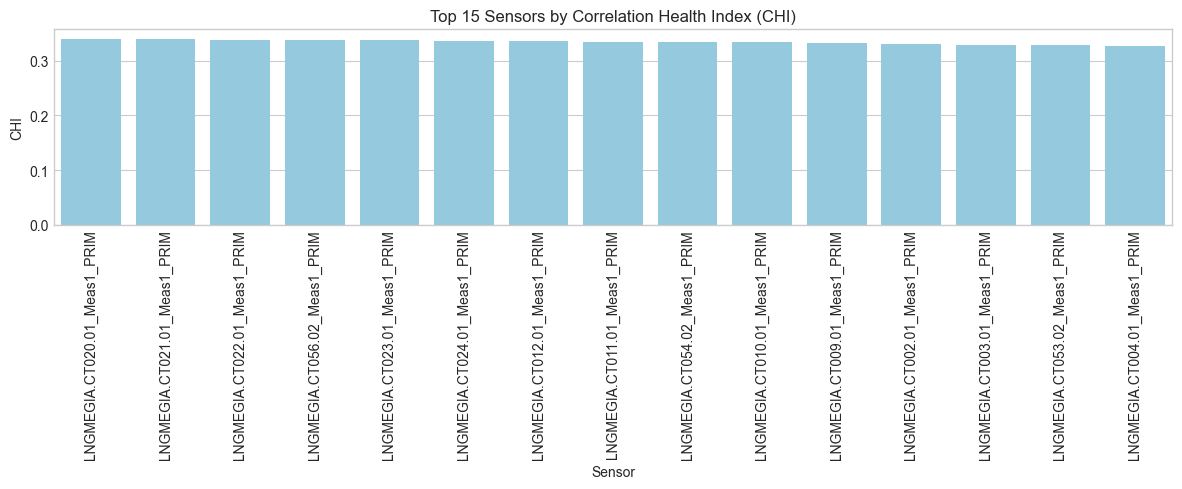

CHI results saved to: /Users/yasmine/Kongsberg/data/derived/correlation_health_index.csv


In [11]:
def compute_chi(clean_dir, output_dir, show_top=15):
    files = [f for f in os.listdir(clean_dir) if f.endswith("_cleaned.csv")]
    data_frames = []

    for f in files:
        df = pd.read_csv(
            os.path.join(clean_dir, f),
            usecols=["Timestamp", "Value"],
            parse_dates=["Timestamp"]
        )
        df.rename(columns={"Value": f.replace("_cleaned.csv", "")}, inplace=True)
        data_frames.append(df)

    merged = data_frames[0]
    for df in data_frames[1:]:
        merged = pd.merge(merged, df, on="Timestamp", how="outer")

    merged = merged.set_index("Timestamp").interpolate(limit_direction="both")
    corr_matrix = merged.corr()
    chi = corr_matrix.mean(axis=1).sort_values(ascending=False).reset_index()
    chi.columns = ["Sensor", "CHI"]

    chi_path = os.path.join(output_dir, "correlation_health_index.csv")
    chi.to_csv(chi_path, index=False)

    plt.figure(figsize=(12, 5))
    sns.barplot(x="Sensor", y="CHI", data=chi.head(show_top), color="skyblue")
    plt.xticks(rotation=90)
    plt.title(f"Top {show_top} Sensors by Correlation Health Index (CHI)")
    plt.tight_layout()
    plt.show()

    print(f"CHI results saved to: {chi_path}")
    return chi

DERIVED_DIR = "/Users/yasmine/Kongsberg/data/derived"
os.makedirs(DERIVED_DIR, exist_ok=True)
chi_df = compute_chi(CLEAN_DIR, DERIVED_DIR)


- CHI values are very close (~0.33 across all top sensors).

- This indicates strong, uniform inter-sensor correlation

**Optionally** compute average CHI per subsystem (group by category from spreadsheet.) to see which subsystem is best aligned.

### Average CHI Per Subsystem

The excel sheet for the subsystem is uploaded then the sensors are devided into subsets.

In [48]:
# --- Paths ---
TAG_PATH = "/Users/yasmine/Kongsberg/data/mapping/TagOverview.xlsx"
MAP_PATH = "/Users/yasmine/Kongsberg/data/mapping/sensor_groups.csv"
os.makedirs(os.path.dirname(MAP_PATH), exist_ok=True)

# --- Load Excel file ---
df = pd.read_excel(TAG_PATH)

# --- Clean column names ---
df.columns = df.columns.str.strip().str.replace(" ", "_")

# --- Define measurement type extractor ---
def detect_measurement_type(name):
    if pd.isnull(name):
        return None
    name_lower = name.lower()

    if "vol" in name_lower:
        return "Volume"
    elif "press" in name_lower:
        return "Pressure"
    elif "temp" in name_lower:
        return "Temperature"
    elif "level" in name_lower:
        return "Level"
    elif "vap" in name_lower:
        return "Vapour_Temperature"
    elif "bottom" in name_lower or "top" in name_lower or "middle" in name_lower:
        return "Tank_Temperature_Profile"
    else:
        return "Other"

# --- Apply measurement group ---
df["Subsystem"] = df["Name"].apply(detect_measurement_type)

# --- Keep only essential columns ---
mapping_df = df[["Name", "Tag", "Subsystem"]].dropna().reset_index(drop=True)

# --- Save to CSV ---
mapping_df.to_csv(MAP_PATH, index=False)
print(f"Saved measurement-based mapping to {MAP_PATH}")
print(mapping_df.head(20))


Saved measurement-based mapping to /Users/yasmine/Kongsberg/data/mapping/sensor_groups.csv
                           Name                              Tag    Subsystem
0           Cargo_CT1_Volume_m3     LNGMEGIA.CT030.13/Meas1/PRIM       Volume
1           Cargo_CT2_Volume_m3     LNGMEGIA.CT031.13/Meas1/PRIM       Volume
2           Cargo_CT3_Volume_m3     LNGMEGIA.CT032.13/Meas1/PRIM       Volume
3           Cargo_CT4_Volume_m3     LNGMEGIA.CT033.13/Meas1/PRIM       Volume
4            Cargo_CT_Volume_m3  LNGMEGIA.CT_TOTALVOL/Meas1/PRIM       Volume
5   Cargo_CT1_Level_Corrected_m     LNGMEGIA.CT030.12/Meas1/PRIM        Level
6   Cargo_CT2_Level_Corrected_m     LNGMEGIA.CT031.12/Meas1/PRIM        Level
7   Cargo_CT3_Level_Corrected_m     LNGMEGIA.CT032.12/Meas1/PRIM        Level
8   Cargo_CT4_Level_Corrected_m     LNGMEGIA.CT032.12/Meas1/PRIM        Level
9    Cargo_CT1_Liquid_Temp_degC     LNGMEGIA.CT053.01/Meas1/PRIM  Temperature
10   Cargo_CT2_Liquid_Temp_degC     LNGMEGIA.CT054.

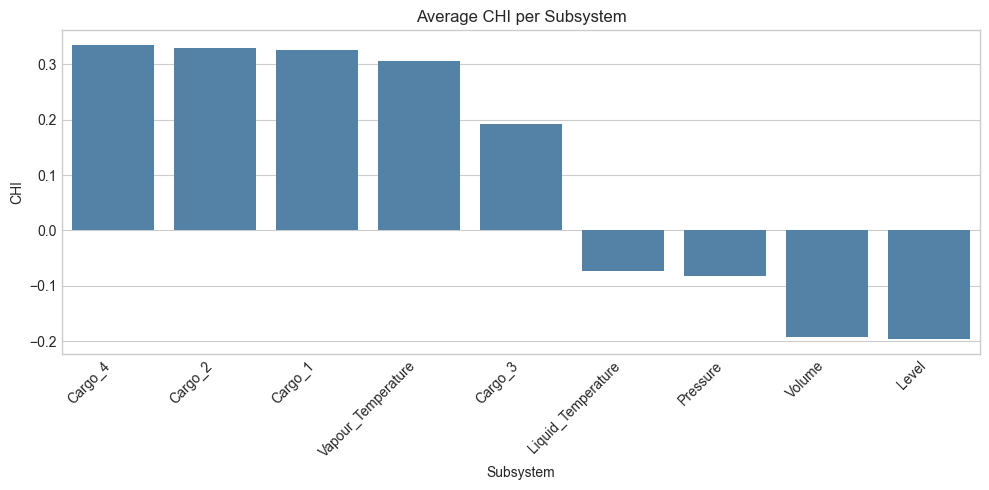

,Subsystem,CHI
3,Cargo_4,0.334879
1,Cargo_2,0.329364
0,Cargo_1,0.326583
7,Vapour_Temperature,0.306035
2,Cargo_3,0.192084
5,Liquid_Temperature,-0.073491
6,Pressure,-0.082836
8,Volume,-0.192895
4,Level,-0.196818


In [49]:
chi = pd.read_csv(os.path.join(DERIVED_DIR, "correlation_health_index.csv"))  # Sensor, CHI, CHI_Band
mapping = pd.read_csv(MAP_PATH)  # Tag, Subsystem (required)

def normalize_tag_to_clean(tag: str) -> str:
    # "LNGMEGIA.CT030.13/Meas1/PRIM" -> "LNGMEGIA.CT030.13_Meas1_PRIM"
    return tag.replace("/", "_")

mapping["Sensor"] = mapping["Tag"].apply(normalize_tag_to_clean)
chi_map = chi.merge(mapping[["Sensor", "Subsystem"]], on="Sensor", how="left")

missing = chi_map["Subsystem"].isna().sum()
if missing > 0:
    print(f"Warning: {missing} sensors missing Subsystem mapping. Check mapping file.")

subsys_chi = (
    chi_map.dropna(subset=["Subsystem"])
          .groupby("Subsystem", as_index=False)["CHI"].mean()
          .sort_values("CHI", ascending=False)
)

plt.figure(figsize=(10,5))
sns.barplot(data=subsys_chi, x="Subsystem", y="CHI", color="steelblue")
plt.xticks(rotation=45, ha="right")
plt.title("Average CHI per Subsystem")
plt.tight_layout()
plt.show()

display(subsys_chi.head(10))

- Cargo_1, Cargo_2, Cargo_4, Vapour_Temperature, Cargo_3 → all have positive CHI (~0.2–0.35)

    - These subsystems are functioning stably and maintaining good correlation behavior.

    - Their sensors’ readings are coherent with the overall system’s patterns.

- Liquid_Temperature, Pressure → slightly negative CHI (~–0.05 to –0.1)

    - These show mild inconsistency — possibly sensor drift, noise, or physical decoupling from expected process variables.

- Volume and Level → strongly negative CHI (~–0.2)

    - These subsystems are least correlated with the rest.

    - Potential causes:

        - Volume/level sensors may fluctuate due to loading/unloading processes or independent operations.

        - Could also indicate calibration issues or missing data points.

## Sensor Reliability Index (SRI)

Computing SRI: 100%|██████████| 45/45 [01:08<00:00,  1.53s/it]


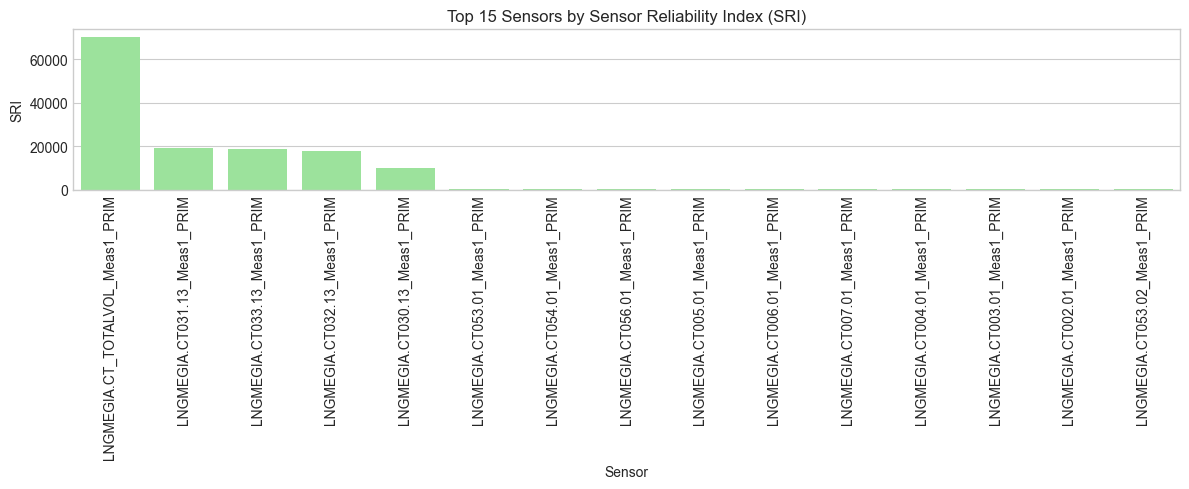

SRI results saved to: /Users/yasmine/Kongsberg/data/derived/sensor_reliability_index.csv


In [12]:
def compute_sri(clean_dir, output_dir):
    results = []

    for f in tqdm(os.listdir(clean_dir), desc="Computing SRI"):
        if not f.endswith("_cleaned.csv"):
            continue
        sensor_name = f.replace("_cleaned.csv", "")
        df = pd.read_csv(os.path.join(clean_dir, f), parse_dates=["Timestamp"])
        if "Value" not in df.columns or df["Value"].nunique() < 2:
            continue

        variance = df["Value"].var()
        mean = df["Value"].mean()
        reliability = (variance / (abs(mean) + 1e-9))  # normalized variance

        results.append({"Sensor": sensor_name, "SRI": reliability})

    sri_df = pd.DataFrame(results).sort_values("SRI", ascending=False)
    sri_path = os.path.join(output_dir, "sensor_reliability_index.csv")
    sri_df.to_csv(sri_path, index=False)

    plt.figure(figsize=(12, 5))
    sns.barplot(x="Sensor", y="SRI", data=sri_df.head(15), color="lightgreen")
    plt.xticks(rotation=90)
    plt.title("Top 15 Sensors by Sensor Reliability Index (SRI)")
    plt.tight_layout()
    plt.show()

    print(f"SRI results saved to: {sri_path}")
    return sri_df

sri_df = compute_sri(CLEAN_DIR, DERIVED_DIR)


- One sensor (LNGMEGA_CT.TOTALVOL.Meas1_PRIM) dominates — high variance or dynamic range.

- Others drop sharply → the SRI distribution is highly skewed, possibly due to differences in measurement units or scaling.

- However, the metric itself works (no NaNs or negatives), so the computation is stable.

    **Forward**
    - Normalize per-sensor group (e.g., z-score or min-max within subsystem).

    - Add a boxplot of SRI across all sensors to detect outliers visually. !! check for above/below level.

    - Later, combine SRI + CHI → (SRI * CHI) composite index for ranking sensor importance vs health.

    The diagnostics (CHI, SRI, Heartbeat) can be merged, however that will be done at a later time for the dashboard/Visualizations.

### SRI NORMALIZATION PER SUBSYSTEM

In [50]:
sri = pd.read_csv(os.path.join(DERIVED_DIR, "sensor_reliability_index.csv"))  # Sensor, SRI, SRI_Band
mapping = pd.read_csv(MAP_PATH)

def normalize_tag_to_clean(tag: str) -> str:
    return tag.replace("/", "_")

mapping["Sensor"] = mapping["Tag"].apply(normalize_tag_to_clean)

sri_map = sri.merge(mapping[["Sensor", "Subsystem"]], on="Sensor", how="left")

def zscore(g):
    return (g - g.mean()) / (g.std(ddof=0) + 1e-12)

sri_map["SRI_z_in_subsys"] = sri_map.groupby("Subsystem")["SRI"].transform(zscore)

# Save normalized SRI for downstream use
sri_norm_path = os.path.join(DERIVED_DIR, "sensor_reliability_index_normalized.csv")
sri_map.to_csv(sri_norm_path, index=False)
print(f"Saved: {sri_norm_path}")
display(sri_map.head(5))

Saved: /Users/yasmine/Kongsberg/data/derived/sensor_reliability_index_normalized.csv


,Sensor,SRI,SRI_Band,Subsystem,SRI_z_in_subsys
0,LNGMEGIA.CT_TOTALVOL_Meas1_PRIM,70139.966532,bad,Volume,1.975274
1,LNGMEGIA.CT031.13_Meas1_PRIM,19184.061646,bad,Volume,-0.365157
2,LNGMEGIA.CT033.13_Meas1_PRIM,18870.549692,bad,Volume,-0.379557
3,LNGMEGIA.CT032.13_Meas1_PRIM,17625.431401,bad,Volume,-0.436746
4,LNGMEGIA.CT030.13_Meas1_PRIM,9851.302706,bad,Volume,-0.793815


### GLOBAL SRI BOXLOT + OUTLIER LIST (Tukey fences)

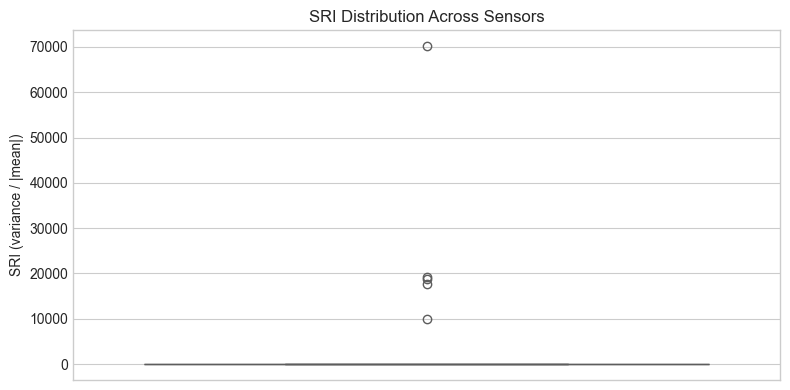

Lower fence (below): -55.8354 | Upper fence (above): 118.1312

Sensors with unusually LOW SRI (very stable; verify not frozen/stuck):


,Sensor,SRI,SRI_Band



Sensors with unusually HIGH SRI (very unstable vs mean):


,Sensor,SRI,SRI_Band
0,LNGMEGIA.CT_TOTALVOL_Meas1_PRIM,70139.966532,bad
1,LNGMEGIA.CT031.13_Meas1_PRIM,19184.061646,bad
2,LNGMEGIA.CT033.13_Meas1_PRIM,18870.549692,bad
3,LNGMEGIA.CT032.13_Meas1_PRIM,17625.431401,bad
4,LNGMEGIA.CT030.13_Meas1_PRIM,9851.302706,bad


In [51]:
sri = pd.read_csv(os.path.join(DERIVED_DIR, "sensor_reliability_index.csv"))  # Sensor, SRI, SRI_Band

plt.figure(figsize=(8,4))
sns.boxplot(y=sri["SRI"])  # lower is better in your definition
plt.title("SRI Distribution Across Sensors")
plt.ylabel("SRI (variance / |mean|)")
plt.tight_layout()
plt.show()

# Tukey outlier detection
Q1 = sri["SRI"].quantile(0.25)
Q3 = sri["SRI"].quantile(0.75)
IQR = Q3 - Q1
lower_fence = Q1 - 1.5 * IQR
upper_fence = Q3 - 1.5 * IQR  # Note: for SRI "lower is better" but outliers both sides are interesting
upper_fence = Q3 + 1.5 * IQR  # correct upper fence

below = sri[sri["SRI"] < lower_fence]
above = sri[sri["SRI"] > upper_fence]

print(f"Lower fence (below): {lower_fence:.4f} | Upper fence (above): {upper_fence:.4f}")
print("\nSensors with unusually LOW SRI (very stable; verify not frozen/stuck):")
display(below.sort_values("SRI"))
print("\nSensors with unusually HIGH SRI (very unstable vs mean):")
display(above.sort_values("SRI", ascending=False))

- Most sensors have low SRI (clustered near 0) → stable, consistent readings.

- A few outliers (above 10,000–70,000) → sensors with extremely high variance relative to mean.

    - These outliers likely correspond to malfunctioning, noisy, or process-transition sensors.

    - Possibly the same subsystems that had low CHI (Volume/Level).

    - The extreme 70,000 SRI value likely indicates a flat mean near zero combined with strong noise — a common sign of sensor miscalibration or stuck-at-zero readings.

- Overall system reliability is good, but a handful of sensors are behaving erratically.

- These high-variance sensors should be flagged for diagnostics, as they’re likely driving the negative CHI in certain subsystems.

**Recommended checks:**

- Plot the raw time series for each low-SRI sensor.

- Confirm whether values change at all over time.

- If flat → flag as “stuck/frozen”.

- If physically expected (e.g., constant tank pressure during storage) → mark as stable but healthy.

In [53]:
# --- Paths ---
SRI_PATH = "/Users/yasmine/Kongsberg/data/derived/sensor_reliability_index.csv"

# --- Load data ---
sri_df = pd.read_csv(SRI_PATH)

# --- Ensure correct columns ---
# Expecting columns: Sensor, SRI (or equivalent)
if "SRI" not in sri_df.columns:
    # Try to find the correct column name (variance/mean, etc.)
    sri_col = [c for c in sri_df.columns if "SRI" in c or "variance" in c.lower()]
    if sri_col:
        sri_df.rename(columns={sri_col[0]: "SRI"}, inplace=True)
    else:
        raise ValueError("No SRI-like column found in the CSV.")

# --- Compute fences using IQR rule ---
Q1 = sri_df["SRI"].quantile(0.25)
Q3 = sri_df["SRI"].quantile(0.75)
IQR = Q3 - Q1
lower_fence = Q1 - 1.5 * IQR
upper_fence = Q3 + 1.5 * IQR

print(f"Lower fence (below): {lower_fence:.4f} | Upper fence (above): {upper_fence:.4f}")

# --- Identify outliers ---
low_sri = sri_df[sri_df["SRI"] < lower_fence].copy()
high_sri = sri_df[sri_df["SRI"] > upper_fence].copy()

# --- Display results ---
print("\nSensors with unusually LOW SRI (very stable; verify not frozen/stuck):")
display(low_sri[["Sensor", "SRI"]] if "Sensor" in low_sri.columns else low_sri.head())

print("\nSensors with unusually HIGH SRI (noisy or unstable; verify calibration/signal spikes):")
display(high_sri[["Sensor", "SRI"]] if "Sensor" in high_sri.columns else high_sri.head())



Lower fence (below): -55.8354 | Upper fence (above): 118.1312

Sensors with unusually LOW SRI (very stable; verify not frozen/stuck):


,Sensor,SRI



Sensors with unusually HIGH SRI (noisy or unstable; verify calibration/signal spikes):


,Sensor,SRI
0,LNGMEGIA.CT_TOTALVOL_Meas1_PRIM,70139.966532
1,LNGMEGIA.CT031.13_Meas1_PRIM,19184.061646
2,LNGMEGIA.CT033.13_Meas1_PRIM,18870.549692
3,LNGMEGIA.CT032.13_Meas1_PRIM,17625.431401
4,LNGMEGIA.CT030.13_Meas1_PRIM,9851.302706


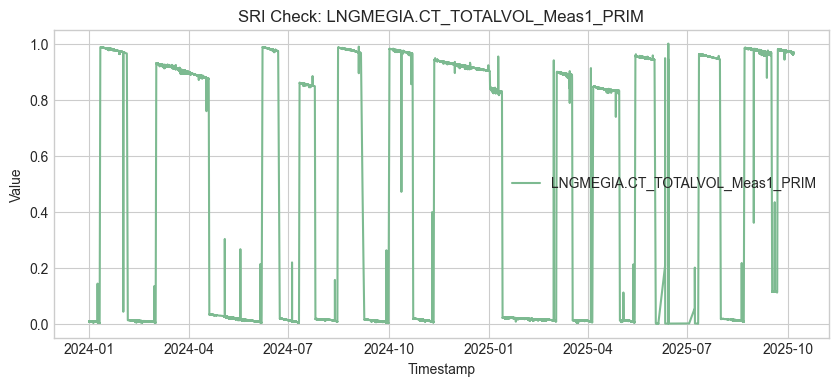

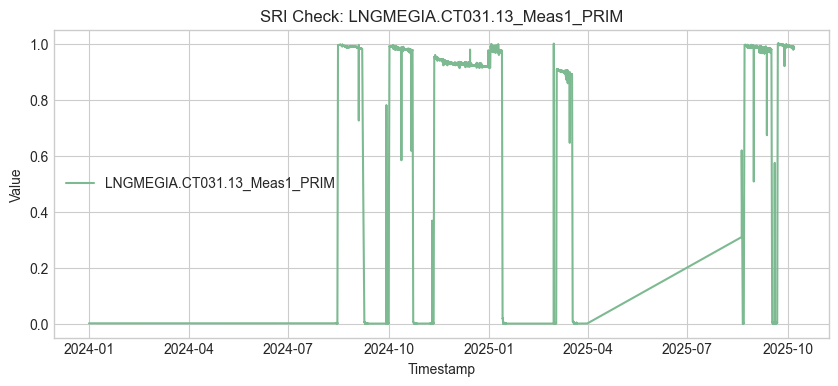

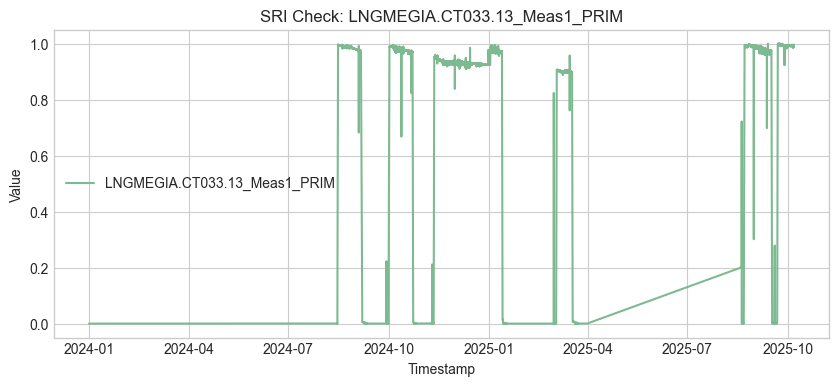

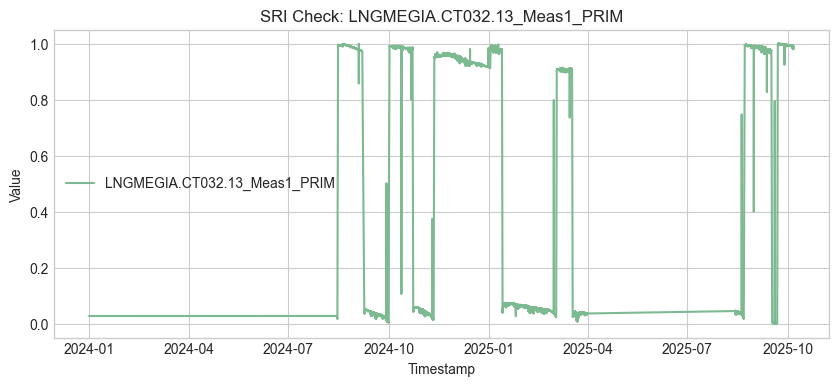

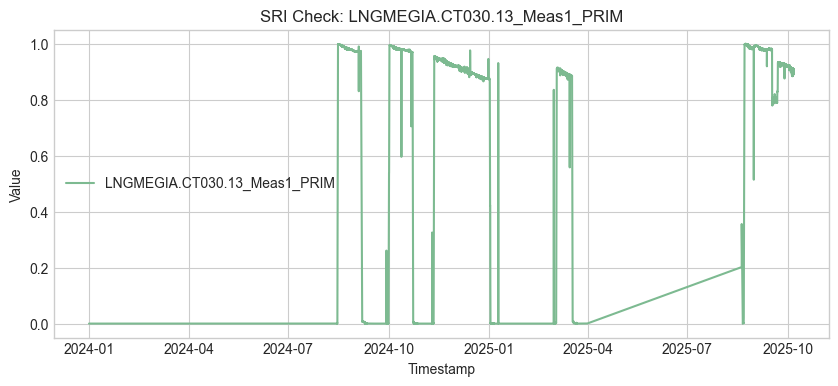

In [54]:
# Quick plots for visual inspection
import matplotlib.pyplot as plt

noisy_sensors = [
    "LNGMEGIA.CT_TOTALVOL_Meas1_PRIM",
    "LNGMEGIA.CT031.13_Meas1_PRIM",
    "LNGMEGIA.CT033.13_Meas1_PRIM",
    "LNGMEGIA.CT032.13_Meas1_PRIM",
    "LNGMEGIA.CT030.13_Meas1_PRIM",
]

for s in noisy_sensors:
    plt.figure(figsize=(10,4))
    plt.plot(merged[s], label=s)
    plt.title(f"SRI Check: {s}")
    plt.xlabel("Timestamp")
    plt.ylabel("Value")
    plt.legend() 
    plt.show()


- Each time series exhibits sharp, step-like transitions between 0 and 1 normalized values.

- The frequent “flatline–jump–flatline” behavior suggests that sensors are reporting discrete state changes or undergoing calibration cycles rather than continuous physical measurements.

- Prolonged flat regions with sudden drops and recoveries could indicate communication delays, buffer resets, or sensor saturation limits.

- The extremely high SRI values are consistent with noisy or intermittently unstable sensors, likely affecting CHI negatively.

## CHI & SRI Classification

The two indexes are going to be classified in the following manner:

- CHI ≥ 0.33  →  "good"             # Strong correlation with fleet/network
- CHI ≥ 0.20  →  "moderate"         # Acceptable correlation
- CHI < 0.20  →  "bad"              # Weak correlation - investigate!

---

- Bottom 33% of SRI values  →  "good"      # Most stable sensors
- Middle 33% of SRI values  →  "moderate"  # Average variability
- Top 33% of SRI values     →  "bad"       # Most variable/noisy sensors

In [ ]:
# === CHI & SRI CLASSIFICATION ===
chi_path = os.path.join(DERIVED_DIR, "correlation_health_index.csv")
sri_path = os.path.join(DERIVED_DIR, "sensor_reliability_index.csv")

chi = pd.read_csv(chi_path)         # columns: Sensor, CHI
sri = pd.read_csv(sri_path)         # columns: Sensor, SRI

# --- CHI bands (coach baseline: 0.33 = good). Adjust here if needed.
def chi_band(x):
    if x >= 0.33:         # good alignment with the fleet/network
        return "good"
    elif x >= 0.20:       # moderate / acceptable
        return "moderate"
    else:
        return "bad"      # weak correlation; investigate

chi["CHI_Band"] = chi["CHI"].apply(chi_band)

# --- SRI interpretation:
# Your SRI = variance / |mean|  (lower is better = more stable/reliable)
# We'll use global quantiles to band it (it can be switched to fixed thresholds if desired).
q_low, q_mid = sri["SRI"].quantile([0.33, 0.66])

def sri_band(x):
    if x <= q_low:        # lowest variability → best reliability
        return "good"
    elif x <= q_mid:
        return "moderate"
    else:
        return "bad"      # highly variable for its magnitude

sri["SRI_Band"] = sri["SRI"].apply(sri_band)

# Save back (overwriting is fine; you’re in /data/derived)
chi.to_csv(chi_path, index=False)
sri.to_csv(sri_path, index=False)

print("Updated CHI/SRI with bands.")
display(chi.head(3))
display(sri.head(3))

Updated CHI/SRI with bands.


,Sensor,CHI,CHI_Band
0,LNGMEGIA.CT020.01_Meas1_PRIM,0.340213,good
1,LNGMEGIA.CT021.01_Meas1_PRIM,0.339043,good
2,LNGMEGIA.CT022.01_Meas1_PRIM,0.338181,good


,Sensor,SRI,SRI_Band
0,LNGMEGIA.CT_TOTALVOL_Meas1_PRIM,70139.966532,bad
1,LNGMEGIA.CT031.13_Meas1_PRIM,19184.061646,bad
2,LNGMEGIA.CT033.13_Meas1_PRIM,18870.549692,bad


## Health Summary

In [ ]:
heartbeat = pd.read_csv("/Users/yasmine/Kongsberg/data/heartbeat/heartbeat_status.csv")
chi = pd.read_csv("/Users/yasmine/Kongsberg/data/derived/correlation_health_index.csv")
sri = pd.read_csv("/Users/yasmine/Kongsberg/data/derived/sensor_reliability_index.csv")

summary = (
    heartbeat.merge(chi, on="Sensor", how="left")
             .merge(sri, on="Sensor", how="left")
             .fillna(0)
)
summary["Composite_Health"] = summary["CHI"] * (1 / (1 + summary["SRI"]))
summary.to_csv("/Users/yasmine/Kongsberg/data/derived/sensor_health_summary.csv", index=False)


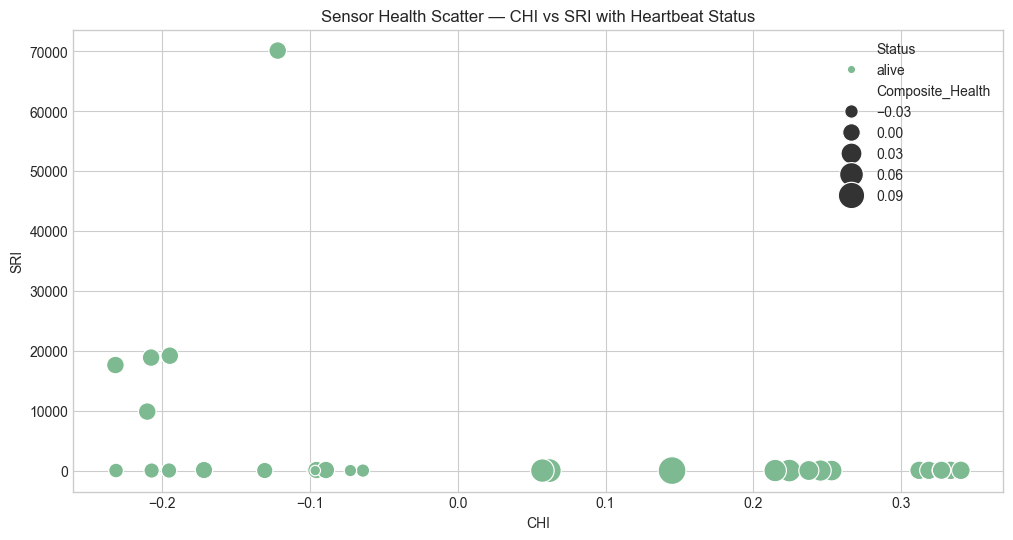

In [ ]:
plt.figure(figsize=(12,6))
sns.scatterplot(data=summary, x="CHI", y="SRI", hue="Status", size="Composite_Health", sizes=(50,400))
plt.title("Sensor Health Scatter — CHI vs SRI with Heartbeat Status")
plt.show()

**Sensors cluster into three visible groups:**

- High CHI / Low SRI: healthy, consistent sensors — optimal operation.

- Low CHI / High SRI: unstable or noisy sensors — potential malfunction or environmental interference.

- Negative CHI / High SRI: sensors inversely correlated with others — possible calibration offset or subsystem drift.

The consistent green “alive” status across all points confirms that operational status alone doesn’t imply data quality.

## Granger Causality Computation

Tests whether one sensor's time series statistically predicts another's.

In [ ]:
OUTPUT_DIR = "/Users/yasmine/Kongsberg/data/network"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# --- Merge only essential columns: Timestamp + Value_norm ---
sensor_dfs = []
for f in os.listdir(CLEAN_DIR):
    if f.endswith("_cleaned.csv"):
        df = pd.read_csv(os.path.join(CLEAN_DIR, f), parse_dates=["Timestamp"])
        # Use normalized values if available
        if "Value_norm" in df.columns:
            df = df[["Timestamp", "Value_norm"]]
            df.rename(columns={"Value_norm": f.replace("_cleaned.csv", "")}, inplace=True)
        elif "Value" in df.columns:
            df = df[["Timestamp", "Value"]]
            df.rename(columns={"Value": f.replace("_cleaned.csv", "")}, inplace=True)
        else:
            continue
        sensor_dfs.append(df)

# Merge all sensors on Timestamp safely
merged = sensor_dfs[0]
for df in sensor_dfs[1:]:
    merged = pd.merge(merged, df, on="Timestamp", how="outer")

merged = merged.set_index("Timestamp").interpolate(limit_direction="both").dropna()

print(f"Merged dataframe shape: {merged.shape}")
print(f"Number of sensors: {len(merged.columns)}")

# --- Run Granger Causality Tests ---
results = []
sensors = merged.columns
print("Running pairwise Granger causality tests...")

for i in tqdm(sensors, desc="Sensor i"):
    for j in sensors:
        if i == j:
            continue
        try:
            test = grangercausalitytests(merged[[i, j]], maxlag=3, verbose=False)
            p_value = test[1][0]['ssr_ftest'][1]
            if p_value < 0.05:
                results.append({
                    "Cause": i,
                    "Effect": j,
                    "p_value": p_value
                })
        except Exception:
            continue

granger_df = pd.DataFrame(results)
granger_path = os.path.join(OUTPUT_DIR, "granger_causality_results.csv")
granger_df.to_csv(granger_path, index=False)

print(f"Granger causality results saved to: {granger_path}")
display(granger_df.head())

    This is very computationally expensive and not effecient while saving data (if the kernel crashes while doing sensor i without getting to the last sensor nothing is saved). So a new plan is drafted; the sensors will be split into batches of 3

In [ ]:
OUTPUT_DIR = "/Users/yasmine/Kongsberg/data/network"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# --- Merge only essential columns: Timestamp + Value_norm ---
sensor_dfs = []
for f in os.listdir(CLEAN_DIR):
    if f.endswith("_cleaned.csv"):
        df = pd.read_csv(os.path.join(CLEAN_DIR, f), parse_dates=["Timestamp"])
        if "Value_norm" in df.columns:
            df = df[["Timestamp", "Value_norm"]]
            df.rename(columns={"Value_norm": f.replace("_cleaned.csv", "")}, inplace=True)
        elif "Value" in df.columns:
            df = df[["Timestamp", "Value"]]
            df.rename(columns={"Value": f.replace("_cleaned.csv", "")}, inplace=True)
        else:
            continue
        sensor_dfs.append(df)

# Merge all sensors on Timestamp safely
merged = sensor_dfs[0]
for df in sensor_dfs[1:]:
    merged = pd.merge(merged, df, on="Timestamp", how="outer")

merged = merged.set_index("Timestamp").interpolate(limit_direction="both").dropna()

sensors = merged.columns.tolist()
print(f"Merged dataframe shape: {merged.shape}")
print(f"Total sensors: {len(sensors)}")

# Split into batches of 3
batch_size = 3
batches = [sensors[i:i + batch_size] for i in range(0, len(sensors), batch_size)]
print(f"Created {len(batches)} batches of up to {batch_size} sensors each.")


Merged dataframe shape: (927360, 45)
Total sensors: 45
Created 15 batches of up to 3 sensors each.


In [ ]:
def run_granger_batch(batch_num, merged, batches, output_dir="/Users/yasmine/Kongsberg/data/network"):
    """
    Run Granger causality on one batch of sensors and append results to CSV.
    - batch_num: 1-based batch index
    - merged: merged dataframe (Timestamp-indexed)
    - batches: list of sensor batches (from previous cell)
    - output_dir: where to save cumulative results
    """

    output_path = os.path.join(output_dir, "granger_causality_results.csv")

    # --- Validate batch ---
    if batch_num < 1 or batch_num > len(batches):
        raise ValueError(f"Batch number {batch_num} is invalid. Choose 1-{len(batches)}.")

    batch = batches[batch_num - 1]
    sensors = merged.columns.tolist()
    print(f"\nRunning Granger Causality for Batch {batch_num}/{len(batches)}")
    print(f"Sensors in this batch ({len(batch)}): {batch}")

    results = []
    total_tests = 0
    failed_tests = 0

    for i in tqdm(batch, desc=f"Batch {batch_num} Sensor i"):
        for j in sensors:
            if i == j:
                continue
            total_tests += 1
            try:
                test = grangercausalitytests(merged[[i, j]], maxlag=3, verbose=False)
                p_value = test[1][0]['ssr_ftest'][1]

                results.append({
                    "Cause": i,
                    "Effect": j,
                    "p_value": p_value,
                    "Causality_Strength": 1 - min(p_value, 1.0)
                })
            except Exception:
                failed_tests += 1
                continue

    print(f"Completed {total_tests} tests ({failed_tests} failed).")
    print(f"Saving results for batch {batch_num}...")

    if not results:
        print(f"No valid pairs processed for batch {batch_num}.")
        return

    # --- Save or append ---
    df_new = pd.DataFrame(results)
    if os.path.exists(output_path):
        df_existing = pd.read_csv(output_path)
        df_all = pd.concat([df_existing, df_new], ignore_index=True)
    else:
        df_all = df_new

    df_all.to_csv(output_path, index=False)
    print(f"Saved {len(df_new)} new results (total now {len(df_all)} rows).")
    print(f"Results file: {output_path}")


After defining the main function I will run it on all 15 batches.

### Running the Test on the batches.

In [ ]:
run_granger_batch(1, merged, batches)


Running Granger Causality for Batch 1/15
Sensors in this batch (3): ['LNGMEGIA.CT007.01_Meas1_PRIM', 'LNGMEGIA.CT026_Meas1_PRIM', 'LNGMEGIA.CT021.01_Meas1_PRIM']


Batch 1 Sensor i: 100%|██████████| 3/3 [02:21<00:00, 47.25s/it]

Completed 132 tests (0 failed).
Saving results for batch 1...
Saved 132 new results (total now 132 rows).
Results file: /Users/yasmine/Kongsberg/data/network/granger_causality_results.csv


In [ ]:
run_granger_batch(2, merged, batches)


Running Granger Causality for Batch 2/15
Sensors in this batch (3): ['LNGMEGIA.CT056.01_Meas1_PRIM', 'LNGMEGIA.CT030.12_Meas1_PRIM', 'LNGMEGIA.CT012.01_Meas1_PRIM']


Batch 2 Sensor i: 100%|██████████| 3/3 [02:22<00:00, 47.55s/it]

Completed 132 tests (0 failed).
Saving results for batch 2...
Saved 132 new results (total now 264 rows).
Results file: /Users/yasmine/Kongsberg/data/network/granger_causality_results.csv


In [ ]:
run_granger_batch(3, merged, batches)


Running Granger Causality for Batch 3/15
Sensors in this batch (3): ['LNGMEGIA.CT015.01_Meas1_PRIM', 'LNGMEGIA.CT032.13_Meas1_PRIM', 'LNGMEGIA.CT028_Meas1_PRIM']


Batch 3 Sensor i: 100%|██████████| 3/3 [02:22<00:00, 47.40s/it]

Completed 132 tests (0 failed).
Saving results for batch 3...
Saved 132 new results (total now 396 rows).
Results file: /Users/yasmine/Kongsberg/data/network/granger_causality_results.csv


In [ ]:
run_granger_batch(4, merged, batches)


Running Granger Causality for Batch 4/15
Sensors in this batch (3): ['LNGMEGIA.CT008.01_Meas1_PRIM', 'LNGMEGIA.CT056.02_Meas1_PRIM', 'LNGMEGIA.CT005.01_Meas1_PRIM']


Batch 4 Sensor i: 100%|██████████| 3/3 [02:25<00:00, 48.56s/it]

Completed 132 tests (0 failed).
Saving results for batch 4...
Saved 132 new results (total now 528 rows).
Results file: /Users/yasmine/Kongsberg/data/network/granger_causality_results.csv


In [ ]:
run_granger_batch(5, merged, batches)


Running Granger Causality for Batch 5/15
Sensors in this batch (3): ['LNGMEGIA.CT_TOTALVOL_Meas1_PRIM', 'LNGMEGIA.CT053.02_Meas1_PRIM', 'LNGMEGIA.CT054.01_Meas1_PRIM']


Batch 5 Sensor i: 100%|██████████| 3/3 [02:32<00:00, 50.71s/it]

Completed 132 tests (0 failed).
Saving results for batch 5...
Saved 132 new results (total now 660 rows).
Results file: /Users/yasmine/Kongsberg/data/network/granger_causality_results.csv


In [ ]:
run_granger_batch(6, merged, batches)


Running Granger Causality for Batch 6/15
Sensors in this batch (3): ['LNGMEGIA.CT023.01_Meas1_PRIM', 'LNGMEGIA.CT018.01_Meas1_PRIM', 'LNGMEGIA.CT029_Meas1_PRIM']


Batch 6 Sensor i: 100%|██████████| 3/3 [02:23<00:00, 47.72s/it]

Completed 132 tests (0 failed).
Saving results for batch 6...
Saved 132 new results (total now 792 rows).
Results file: /Users/yasmine/Kongsberg/data/network/granger_causality_results.csv


In [ ]:
run_granger_batch(7, merged, batches)


Running Granger Causality for Batch 7/15
Sensors in this batch (3): ['LNGMEGIA.CT010.01_Meas1_PRIM', 'LNGMEGIA.CT032.12_Meas1_PRIM', 'LNGMEGIA.CT030.13_Meas1_PRIM']


Batch 7 Sensor i: 100%|██████████| 3/3 [02:23<00:00, 47.76s/it]

Completed 132 tests (0 failed).
Saving results for batch 7...
Saved 132 new results (total now 924 rows).
Results file: /Users/yasmine/Kongsberg/data/network/granger_causality_results.csv


In [ ]:
run_granger_batch(8, merged, batches)


Running Granger Causality for Batch 8/15
Sensors in this batch (3): ['LNGMEGIA.CT017.01_Meas1_PRIM', 'LNGMEGIA.CT024.01_Meas1_PRIM', 'LNGMEGIA.CT053.01_Meas1_PRIM']


Batch 8 Sensor i: 100%|██████████| 3/3 [02:22<00:00, 47.54s/it]

Completed 132 tests (0 failed).
Saving results for batch 8...
Saved 132 new results (total now 1056 rows).
Results file: /Users/yasmine/Kongsberg/data/network/granger_causality_results.csv


In [ ]:
run_granger_batch(9, merged, batches)


Running Granger Causality for Batch 9/15
Sensors in this batch (3): ['LNGMEGIA.CT027_Meas1_PRIM', 'LNGMEGIA.CT054.02_Meas1_PRIM', 'LNGMEGIA.CT002.01_Meas1_PRIM']


Batch 9 Sensor i: 100%|██████████| 3/3 [02:25<00:00, 48.56s/it]

Completed 132 tests (0 failed).
Saving results for batch 9...
Saved 132 new results (total now 1188 rows).
Results file: /Users/yasmine/Kongsberg/data/network/granger_causality_results.csv


In [ ]:
run_granger_batch(10, merged, batches)


Running Granger Causality for Batch 10/15
Sensors in this batch (3): ['LNGMEGIA.CT055.02_Meas1_PRIM', 'LNGMEGIA.CT003.01_Meas1_PRIM', 'LNGMEGIA.CT025.01_Meas1_PRIM']


Batch 10 Sensor i: 100%|██████████| 3/3 [02:23<00:00, 47.74s/it]

Completed 132 tests (0 failed).
Saving results for batch 10...
Saved 132 new results (total now 1320 rows).
Results file: /Users/yasmine/Kongsberg/data/network/granger_causality_results.csv


In [ ]:
run_granger_batch(11, merged, batches)


Running Granger Causality for Batch 11/15
Sensors in this batch (3): ['LNGMEGIA.CT031.13_Meas1_PRIM', 'LNGMEGIA.CT016.01_Meas1_PRIM', 'LNGMEGIA.CT011.01_Meas1_PRIM']


Batch 11 Sensor i: 100%|██████████| 3/3 [02:30<00:00, 50.21s/it]

Completed 132 tests (0 failed).
Saving results for batch 11...
Saved 132 new results (total now 1452 rows).
Results file: /Users/yasmine/Kongsberg/data/network/granger_causality_results.csv


In [ ]:
run_granger_batch(12, merged, batches)


Running Granger Causality for Batch 12/15
Sensors in this batch (3): ['LNGMEGIA.CT033.12_Meas1_PRIM', 'LNGMEGIA.CT019.01_Meas1_PRIM', 'LNGMEGIA.CT055.01_Meas1_PRIM']


Batch 12 Sensor i: 100%|██████████| 3/3 [02:28<00:00, 49.61s/it]

Completed 132 tests (0 failed).
Saving results for batch 12...
Saved 132 new results (total now 1584 rows).
Results file: /Users/yasmine/Kongsberg/data/network/granger_causality_results.csv


In [ ]:
run_granger_batch(13, merged, batches)


Running Granger Causality for Batch 13/15
Sensors in this batch (3): ['LNGMEGIA.CT022.01_Meas1_PRIM', 'LNGMEGIA.CT004.01_Meas1_PRIM', 'LNGMEGIA.CT009.01_Meas1_PRIM']


Batch 13 Sensor i: 100%|██████████| 3/3 [02:34<00:00, 51.46s/it]

Completed 132 tests (0 failed).
Saving results for batch 13...
Saved 132 new results (total now 1716 rows).
Results file: /Users/yasmine/Kongsberg/data/network/granger_causality_results.csv


In [ ]:
run_granger_batch(14, merged, batches)


Running Granger Causality for Batch 14/15
Sensors in this batch (3): ['LNGMEGIA.CT014.01_Meas1_PRIM', 'LNGMEGIA.CT033.13_Meas1_PRIM', 'LNGMEGIA.CT031.12_Meas1_PRIM']


Batch 14 Sensor i: 100%|██████████| 3/3 [02:29<00:00, 49.74s/it]

Completed 132 tests (0 failed).
Saving results for batch 14...
Saved 132 new results (total now 1848 rows).
Results file: /Users/yasmine/Kongsberg/data/network/granger_causality_results.csv


In [ ]:
run_granger_batch(15, merged, batches)


Running Granger Causality for Batch 15/15
Sensors in this batch (3): ['LNGMEGIA.CT013.01_Meas1_PRIM', 'LNGMEGIA.CT020.01_Meas1_PRIM', 'LNGMEGIA.CT006.01_Meas1_PRIM']


Batch 15 Sensor i: 100%|██████████| 3/3 [02:31<00:00, 50.63s/it]

Completed 132 tests (0 failed).
Saving results for batch 15...
Saved 132 new results (total now 1980 rows).
Results file: /Users/yasmine/Kongsberg/data/network/granger_causality_results.csv


## Network Graph

This section constructs a directed, weighted sensor network
that represents statistical and temporal dependencies between sensors.

- Nodes represent sensors.
- Edge weights represent combined reliability (CHI × SRI × correlation strength).
- Edge directions (A → B) are derived using Granger causality tests.

<p align="center">
<img src="/Users/yasmine/Kongsberg/images/download.png" alt="Network Graph" width="400" height="250">
</p>

Network graph constructed and saved.


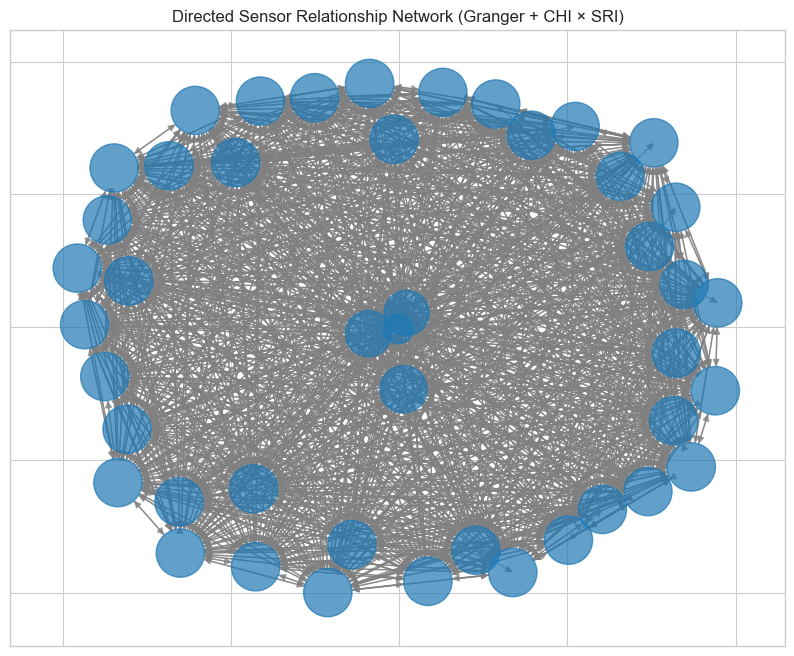

In [ ]:
# Load CHI, SRI, and Granger
chi_df = pd.read_csv(os.path.join(DERIVED_DIR, "correlation_health_index.csv"))
sri_df = pd.read_csv(os.path.join(DERIVED_DIR, "sensor_reliability_index.csv"))
granger_df = pd.read_csv(os.path.join(OUTPUT_DIR, "granger_causality_results.csv"))

# Normalize CHI and SRI
chi_df["CHI_norm"] = (chi_df["CHI"] - chi_df["CHI"].min()) / (chi_df["CHI"].max() - chi_df["CHI"].min())
sri_df["SRI_norm"] = (sri_df["SRI"] - sri_df["SRI"].min()) / (sri_df["SRI"].max() - sri_df["SRI"].min())
health_df = pd.merge(chi_df, sri_df, on="Sensor", how="inner")

# Create graph
G = nx.DiGraph()
for _, row in health_df.iterrows():
    G.add_node(row["Sensor"], CHI=row["CHI_norm"], SRI=row["SRI_norm"])

# Add edges based on Granger results
for _, row in granger_df.iterrows():
    if row["Cause"] in G.nodes and row["Effect"] in G.nodes:
        chi = health_df.loc[health_df["Sensor"] == row["Cause"], "CHI_norm"].values[0]
        sri = health_df.loc[health_df["Sensor"] == row["Cause"], "SRI_norm"].values[0]
        combined_weight = chi * sri
        G.add_edge(row["Cause"], row["Effect"], weight=combined_weight)

# Compute centrality metrics
centrality = nx.eigenvector_centrality(G, weight="weight")
metrics_df = pd.DataFrame({
    "Sensor": list(centrality.keys()),
    "Eigenvector_Centrality": list(centrality.values())
}).sort_values("Eigenvector_Centrality", ascending=False)

metrics_df.to_csv(os.path.join(OUTPUT_DIR, "sensor_network_metrics.csv"), index=False)
nx.write_gexf(G, os.path.join(OUTPUT_DIR, "sensor_network.gexf"))

print("Network graph constructed and saved.")

# Quick visualization
plt.figure(figsize=(10, 8))
pos = nx.spring_layout(G, k=0.3, iterations=30)
node_sizes = [v * 8000 for v in centrality.values()]
nx.draw_networkx(G, pos, with_labels=False, node_size=node_sizes, alpha=0.7, edge_color="gray")
plt.title("Directed Sensor Relationship Network (Granger + CHI × SRI)")
plt.show()

**What This Tells Us**

- The cargo system is highly integrated - sensors don't operate in isolation
- The system is predictable - we can forecast future states from current data
- Cross-tank coupling is significant - operations need holistic oversight

## Next Steps

- Proceed to the **Outlier Verification Layer**, where verified diagnostic results are used to isolate true signal anomalies from normal operational noise.  
- This phase bridges statistical diagnostics and machine learning integration.
